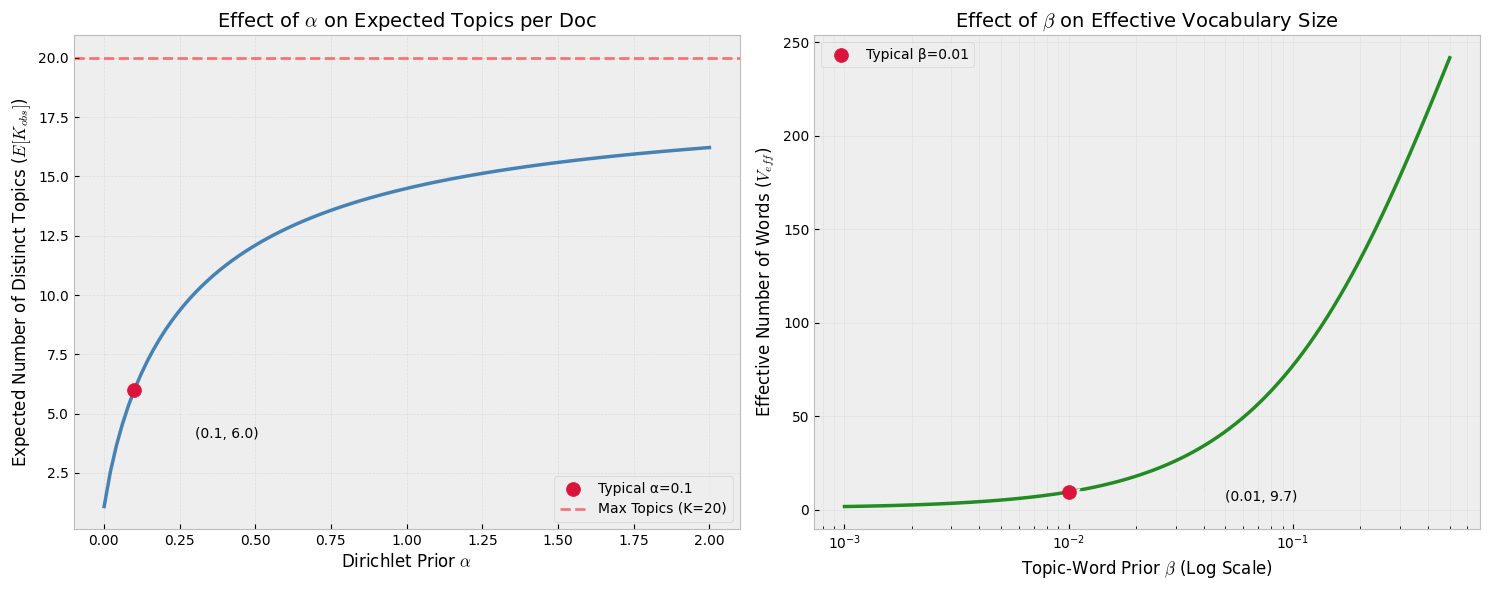

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import loggamma, psi

# 设置全局绘图风格
plt.style.use('bmh')

def calculate_expected_topics(N, K, alpha_range):
    """
    计算每个文档中出现的平均有效主题数 E[K_obs]
    公式基于 Dirichlet-Multinomial 采样的边缘分布
    """
    results = []
    for alpha in alpha_range:
        alpha_0 = K * alpha
        alpha_not_k = (K - 1) * alpha
        
        # 使用 loggamma 保证数值稳定性
        log_p_not_chosen = (loggamma(alpha_not_k + N) + loggamma(alpha_0) - 
                            (loggamma(alpha_not_k) + loggamma(alpha_0 + N)))
        p_not_chosen = np.exp(log_p_not_chosen)
        results.append(K * (1 - p_not_chosen))
    return np.array(results)

def calculate_effective_vocab(V, beta_range):
    """
    计算每个主题下的有效词汇数 V_eff (基于指数熵)
    反映了主题的“专注度”
    """
    results = []
    for beta in beta_range:
        beta_0 = V * beta
        # 预期熵 E[H] = psi(beta_0 + 1) - psi(beta + 1)
        e_h = psi(beta_0 + 1) - psi(beta + 1)
        results.append(np.exp(e_h))
    return np.array(results)

# 1. 设定固定参数
K = 20          # 总主题数
N = 50          # 每个文档的句子/词数
V = 500         # 词典大小

# 2. 设定参数变化范围
alpha_range = np.linspace(0.001, 2.0, 100)
beta_range = np.logspace(-3, -0.3, 100)

# 3. 执行计算
expected_k = calculate_expected_topics(N, K, alpha_range)
effective_v = calculate_effective_vocab(V, beta_range)

# 计算特定标记点
alpha_mark = 0.1
beta_mark = 0.01
k_mark = calculate_expected_topics(N, K, [alpha_mark])[0]
v_mark = calculate_effective_vocab(V, [beta_mark])[0]

# 4. 绘图可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 左图：Alpha 对主题数的影响
ax1.plot(alpha_range, expected_k, lw=2.5, color='steelblue')
ax1.scatter(alpha_mark, k_mark, color='crimson', s=100, zorder=5, label=f'Typical α={alpha_mark}')
ax1.annotate(f'({alpha_mark}, {k_mark:.1f})', xy=(alpha_mark, k_mark), xytext=(alpha_mark+0.2, k_mark-2),
             arrowprops=dict(arrowstyle='->', lw=1.5))
ax1.axhline(y=K, color='r', linestyle='--', alpha=0.5, label=f'Max Topics (K={K})')
ax1.set_title(r'Effect of $\alpha$ on Expected Topics per Doc', fontsize=14)
ax1.set_xlabel(r'Dirichlet Prior $\alpha$', fontsize=12)
ax1.set_ylabel(r'Expected Number of Distinct Topics ($E[K_{obs}]$)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 右图：Beta 对有效词汇数的影响
ax2.plot(beta_range, effective_v, lw=2.5, color='forestgreen')
ax2.scatter(beta_mark, v_mark, color='crimson', s=100, zorder=5, label=f'Typical β={beta_mark}')
ax2.annotate(f'({beta_mark}, {v_mark:.1f})', xy=(beta_mark, v_mark), xytext=(beta_mark*5, v_mark*0.5),
             arrowprops=dict(arrowstyle='->', lw=1.5))
ax2.set_xscale('log')
ax2.set_title(r'Effect of $\beta$ on Effective Vocabulary Size', fontsize=14)
ax2.set_xlabel(r'Topic-Word Prior $\beta$ (Log Scale)', fontsize=12)
ax2.set_ylabel(r'Effective Number of Words ($V_{eff}$)', fontsize=12)
ax2.grid(True, which="both", ls="-", alpha=0.2)
ax2.legend()

plt.tight_layout()
plt.savefig('parameter_sensitivity.png')
plt.show()